## Churn Analysis and Customer Intelligence


In [118]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 

## 1. Import database / data  

In [3]:
# NOTE:
# If you encounter any issues importing the customer_churn.db file,
# run the code below to create the database locally from the provided Excel file OR, can directly import data & start working.

# Otherwise, skip this step and proceed to the next section: Data Import

# Excel file path
# excel_file = 'customer_churn_data_raw.xlsx'

excel_file = 'customer_churn_data_raw.xlsx'

# Create SQLite database connection
# conn = sqlite3.connect('customer_churn.db')

conn  = sqlite3.connect('customer_churn.db')

# Read all sheet names from Excel file
# excel_data = pd.ExcelFile(excel_file)

excel_data = pd.ExcelFile(excel_file)

# Loop through each sheet and store as separate table
# for sheet in excel_data.sheet_names:
#     df = pd.read_excel(excel_file, sheet_name=sheet) # Read sheet into dataframe
#     # Write dataframe to SQLite table
#     df.to_sql(
#         name=sheet,          # Table name = Sheet name
#         con=conn,
#         if_exists='replace', # Replace table if already exists
#         index=False
#     )


for sheet in excel_data.sheet_names:
    df = pd.read_excel(excel_file , sheet_name = sheet)  # read sheet into dataframe
     # Write dataframe to SQLite table
    df.to_sql(
        name=sheet,
        con=conn,
        if_exists = 'replace',  # Replace table if already exists
        index=False
    )
    


# Close connection
# conn.close()

conn.close()

print("All sheets successfully converted into SQLite tables.")

All sheets successfully converted into SQLite tables.


In [4]:
# Data Import: db file to pandas, storing each table to a separate df

# Connect to SQLite database

conn = sqlite3.connect('customer_churn.db')

# sql query to Get all table names

sql_query = """SELECT name 
            FROM sqlite_master
            WHERE type='table';
            """

# read sql query in pandas

tables = pd.read_sql_query(sql_query, conn)


# create dataframe for each table

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)  # Read table into dataframe
    globals()[f"df_{table_name}"] = df   # Create dynamic dataframe name
    print(f"Created dataframe: df_{table_name}")
    



# Close connection

conn.close()









Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [5]:
# Print table names and column names

conn = sqlite3.connect('customer_churn.db')

In [6]:
for table_name in tables['name']:
    print(f"\n Table Name : {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql_query(columns_query, conn)
    print("Columns:")

    print(columns['name'].tolist())


# Close connection
conn.close()


 Table Name : db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

 Table Name : db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

 Table Name : db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [7]:
# PRAGMA is a special command in SQLite used to:
# inspect db information, control db settings, retrieve metadata about tables

## 2. Data cleaning

In [8]:
df_db_customer.head() # customer table 
df_db_customer.tail() # customer table 

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [9]:
df_db_customer.info() # customer table

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [10]:
# a. rename col - name to customer_name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values (using existing data) - country

#### a. Rename Col

In [11]:
# a. rename col - name to customer_name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)

#### b. Drop columns


In [12]:
# df_db_customer.columns[-2:]

# df_db_customer.columns[6:] target columns in positive index 

# different methods to drop columns in pandas dataframe

# df_db_customer.drop(df_db_customer.columns[-2:] , axis=1 , inplace = True)


# df_db_customer.drop(columns = ['interest', 'pincode' , axis=1 ])





#### c. Change data type

In [13]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
 6   interests      4 non-null      object
 7   pincode        0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [14]:
# DOB 

df_db_customer['dob']  =  pd.to_datetime(df_db_customer['dob'])



#### d. Data standardization

In [15]:
# gender 

# df_db_customer['gender'].unique()

df_db_customer['gender'] = df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

In [16]:
df_db_customer['gender'].unique()


array(['Male', 'Female'], dtype=object)

#### e. Fix missing values

In [17]:
# country 

# df_db_customer['country'].isnull().sum()
df_db_customer['country'].isna().sum()



np.int64(3)

In [18]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob,interests,pincode
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07,None,None
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01,None,None


In [19]:
# normal way 

# df_db_customer['country'].fillna('Nahi pata ')

df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [20]:
# country and state - unique value pair

# Creating state → country map from non-null rows

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State

df_db_customer['country'] =   df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [21]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob,interests,pincode


## 2. for subscription head table 

In [22]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [23]:
df_db_subscription.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [24]:
# change data type to date - subscription_start_date , renewal_date, cancellation_date

date_col = ['subscription_start_date' , 'renewal_date' , 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [25]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


## 3. for support  head table 

In [26]:
df_db_support

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,None
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,None
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,None
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [27]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [28]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [29]:
#  drop column 

df_db_support.drop(columns=['col_1' , 'comment'] , axis=1 , inplace=True)

In [30]:
# change data type to date - complaint_date

df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [31]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


## 3. Feature Engineering & Data Analysis

#### Create a new col

In [32]:
# create a new col using existing col - churn flag

# Customer is churned if cancellation_date is not null

df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [33]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


#### Merge Dataframes - JOINs

In [34]:
# first fix support table duplicates then merge
# Note: while merging df's always check the shape before and after

df = (df_db_subscription.merge(df_db_customer , on='customerid' , how='left')
                   .merge(df_db_support , on='customerid' , how='left'))

In [35]:
df_db_subscription.shape

(21, 12)

In [36]:
df.shape

(23, 22)

In [37]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,interests,pincode,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,travel,None,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,None,None,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,None,None,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,movie,None,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,None,None,NaT,NaN,NaN


In [38]:
df_db_customer['customerid'].nunique()

21

In [39]:
df_db_subscription['customerid'].nunique()

21

In [40]:
df_db_support['customerid'].nunique()

7

In [41]:
df_db_support['customerid'].size

9

In [42]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [43]:
df_db_support.groupby('customerid')['customerid'].transform('count')

0    2
1    2
2    1
3    1
4    1
5    1
6    1
7    2
8    2
Name: customerid, dtype: int64

In [44]:
df_db_support['Complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [45]:
df_db_support

,customerid,complaint_date,escalations,csat_score,Complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [46]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [47]:
df_db_support

,customerid,complaint_date,escalations,csat_score,Complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [48]:
# merge df
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [49]:
df.shape

(21, 23)

#### Export dataframe

In [50]:
#  export dataframe to csv file

df.to_csv('exported_churn_data.csv' , index=False)

## Data Analysis

In [51]:
# 1. Churn Rate

In [52]:
df.columns


Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'Complaint_count'],
      dtype='object')

In [53]:
df['churn_flag'].mean()

churn_rate =  df['churn_flag'].mean()*100

print("Churn_rate =" , round(churn_rate,2),"%" )

Churn_rate = 28.57 %


In [54]:
# 2. Retenion Rate

retension_rate = 100 - churn_rate
print("Retension_rate" , round(retension_rate,2),"%")

Retension_rate 71.43 %


In [55]:
# 3. Churn by Plan type

df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')

,plan_type,churn_rate_pct
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [56]:
# 4 a. Churn by state + sum(revenue) & count of users  -- home work **

df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_state')


# 4 b. Churn by subscription type + sum(revenue) & count of users   -- home work **


df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_state')


,subscription_type,churn_rate_state
0,Organic,0.00
1,Paid,16.67
2,Refferal,83.33


In [57]:
# 5. ARPU - Avg Revenue per user

arpu = df['monthly_charges'].mean()

print("ARPU = " , round(arpu,2))

ARPU =  18.85


In [58]:
# homework - calculate customer age

df['customer_age'] = ((df['subscription_start_date'] - df['dob']).dt.days / 365.25).round().astype(int)

df['customer_age']


0     39
1     25
2     45
3     18
4     33
5     34
6     45
7     21
8     38
9     28
10    25
11    42
12    16
13    30
14    40
15    37
16    27
17    21
18    40
19    29
20    45
Name: customer_age, dtype: int64

In [59]:
# Calculate customer age from date of birth
# Using subscription_start_date as reference date for churn analysis context
# (age at the time of subscription)

df['customer_age'] = ((df['subscription_start_date'] - df['dob']).dt.days / 365.25).round().astype(int)

# Alternative: Age as of today (for current age analysis)
# df['customer_age_current'] = ((pd.Timestamp.now() - df['dob']).dt.days / 365.25).round().astype(int)

df[['customerid', 'customer_name', 'dob', 'subscription_start_date', 'customer_age']].head(10)

,customerid,customer_name,dob,subscription_start_date,customer_age
0,0002-ORFBO,keshav,1982-04-12,2021-03-15,39
1,0003-MKNFE,raghav,1995-11-23,2020-08-01,25
2,0004-TLHLJ,lalita,1978-02-15,2022-11-20,45
3,0011-IGKFF,mohan,2001-08-30,2019-05-10,18
4,0013-EXCHZ,mira,1990-05-05,2023-01-05,33
5,0013-MHZWF,durga,1988-12-10,2022-06-18,34
6,0013-SMEOE,mina,1976-09-21,2021-09-30,45
7,0014-BMAQU,madan,1999-03-14,2020-02-14,21
8,0015-UOCOJ,maya,1985-07-07,2023-07-22,38
9,0016-QLJIS,arjun,1993-10-29,2022-04-03,28


In [65]:
# 5. ARPU - Avg Revenue per user

arpu = df['monthly_charges'].mean()


print("ARPU = " , round(arpu,2 ))


ARPU =  18.85


In [ ]:
# homework - calculate customer age


In [68]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,interests,pincode,complaint_date,escalations,csat_score,Complaint_count,customer_age
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,Maharashtra,Male,1982-04-12,travel,None,NaT,NaN,NaN,NaN,39
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,None,None,2024-08-28,Y,10.0,2.0,25


In [74]:
# 6. Avg Customer Tenure
# count of days users has used our service : cancellation date else current date

today =  pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date'] ).dt.days


)

avg_tenure = df['tenure_days'].mean()
print("Avg_Tenure_(days) = ", round,(avg_tenure),0 ) 

Avg_Tenure_(days) =  <built-in function round> 1533.0 0


In [75]:
# 7. Revenue at risk - revenue lost from churned users


revenue_at_risk = df.loc[df['churn_flag'] ==1 , 'monthly_charges' ].sum()
print("Revenue at risk ( rs 'K' ) = " , revenue_at_risk)

Revenue at risk ( rs 'K' ) =  73.94


In [77]:
# 8. Esclation Rate

Esclation_Rate = (df['escalations'] == 'Y').mean()*100
print("Esclation_Rate = " , round(Esclation_Rate,2))

Esclation_Rate =  19.05


In [85]:
# 9. Avg Complaint Per Userdf

Avg_complaint = df['Complaint_count'].sum() / df['customerid'].nunique()

print("Avg Complaint Count per user = ", round(Avg_complaint, 2))


Avg Complaint Count per user =  0.43


In [94]:
# 10. Correlation Esclation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))


Correlation between esclation vs churn is =  nan


c:\Users\shakti\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\shakti\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [96]:
# 11. Create a column using existing col - Churn risk


conditions = [
    (df['churn_score'] < 50 ),
    (df['churn_score'] >=50  ) & (df['churn_score'] <70  ),
    (df['churn_score'] >=70  )
]


choices = ['low','med','high']

df['churn_risk'] = np.select(conditions,choices,default='unknown')


In [97]:
df['churn_risk']

0      low
1     high
2      low
3      low
4     high
5      low
6     high
7      low
8      low
9      low
10     low
11    high
12     low
13    high
14     low
15     med
16     med
17     low
18    high
19     low
20     low
Name: churn_risk, dtype: object

## 4. Visualization using Matplotlib

In [98]:
# best practice to create a copy then work on it

df_visual = df.copy()

In [99]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'Complaint_count', 'customer_age', 'tenure_days', 'churn_risk'],
      dtype='object')

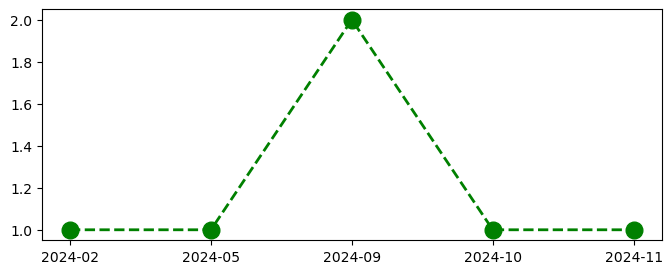

In [119]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df['churn_flag'] ==1 ].groupby('cancellation_month').size()



plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12)

# plt.title('Monthly Churn trend')
# plt.xlabel('Month')
# plt.ylabel('Churned Customers')
# plt.show()

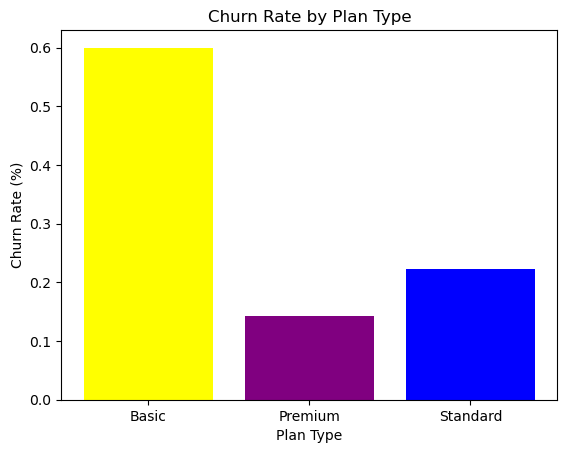

In [127]:
# 4.2 Churn Rate by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = ['yellow', 'purple', 'blue']

plt.Figure(figsize=(7,4))

plt.bar(churn_plan.index , churn_plan.values , color = colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')

plt.show()



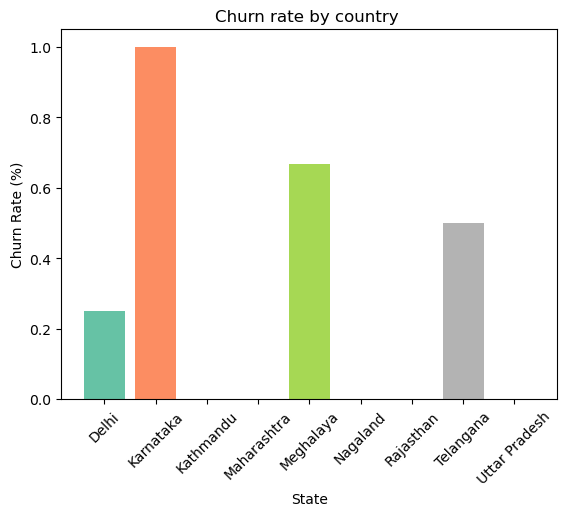

In [132]:
# 4.3 Churn by States

churn_plan =  df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']

colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.Figure(figsize=(12,4))
plt.bar(churn_plan.index , churn_plan.values , color= colors )

plt.title('Churn rate by country ')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()


## Visulaization using Seaborn

In [ ]:
# Heatmap (Correlation Matrix)

In [134]:
# encoding - convert str to numeric so that we can find corr between features

df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'Complaint_count', 'customer_age', 'tenure_days', 'churn_risk',
       'cancellation_month'],
      dtype='object')

In [150]:
import warnings

warnings.filterwarnings("ignore")

In [152]:
# incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes


In [153]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()


,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,0


In [154]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,0
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,0


In [ ]:
# Heatmap (correlation matrix)

<Axes: >

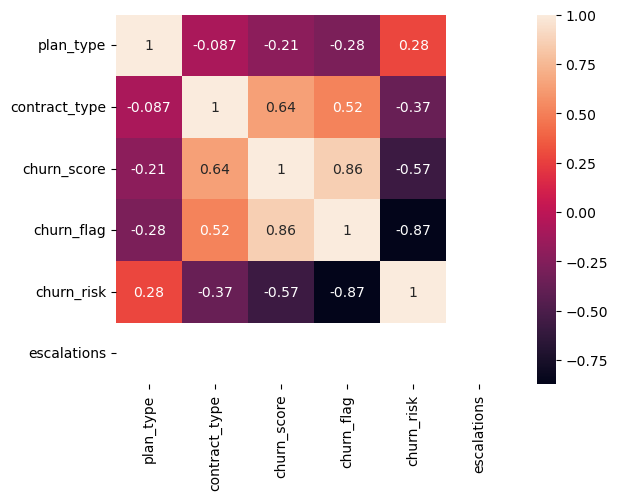

In [156]:
sns.heatmap(df_encoded.corr(),annot=True)

In [157]:
# Correct method of encoding - based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]


order_mapings = {
    'plan_type' : ['Basic' , 'Standard', 'Premium'],
    'contract_type':['Monthly', 'Annual'],
    'churn_risk' : ['low','med','high']


}


for col , order in order_mapings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [159]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()


,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,0


In [158]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,0
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,0


<Axes: >

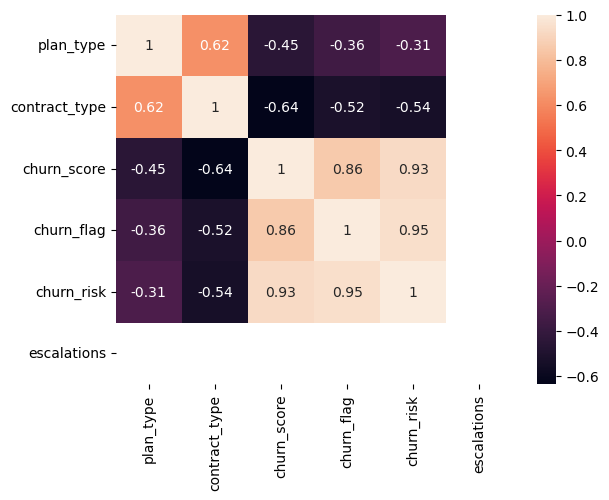

In [160]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

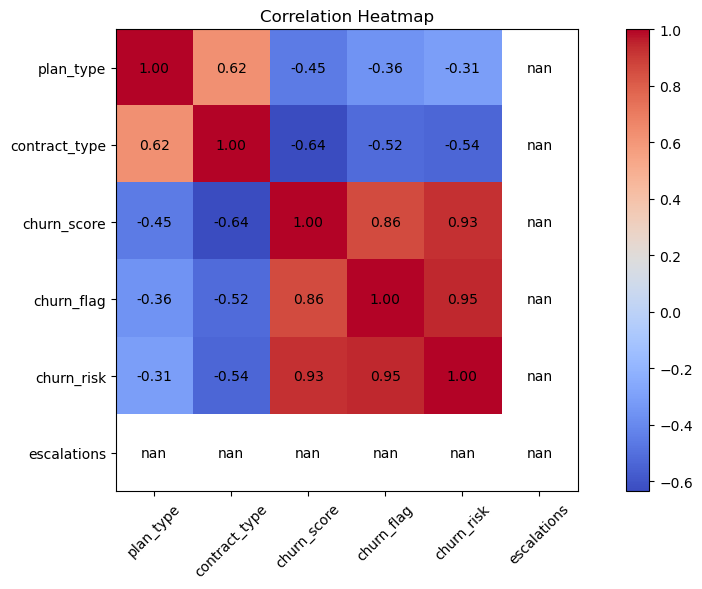

In [161]:
# Heatmap Using Matplotlib - difficult to plot it

corr_matrix = df_encoded.corr() # Correlation matrix

fig, ax = plt.subplots(figsize=(10, 6)) # Create figure

cax = ax.imshow(corr_matrix, cmap='coolwarm') # Heatmap

fig.colorbar(cax) # Add colorbar

# Axis labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticklabels(corr_matrix.columns)

# Annotate values inside cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap') # Title

plt.tight_layout()
plt.show()

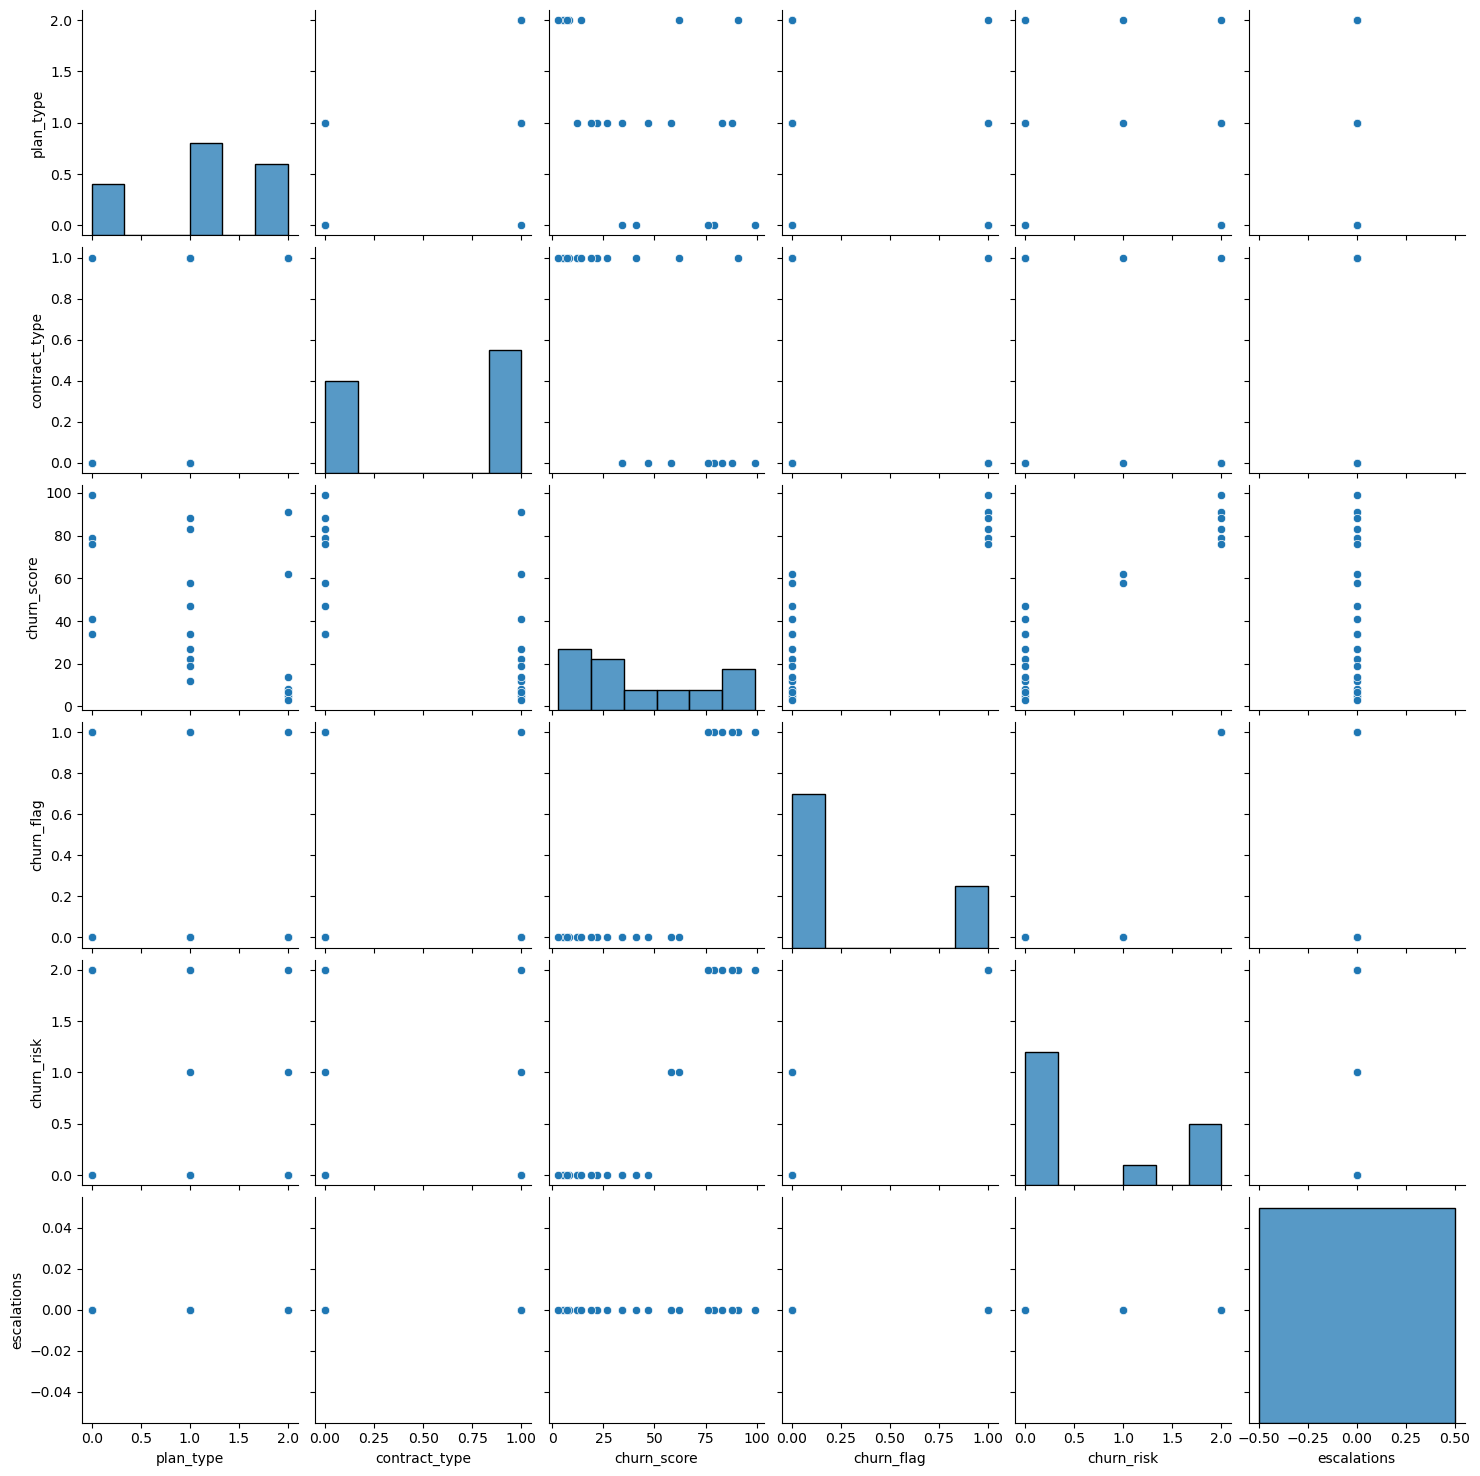

In [162]:
# pairplot - Plot pairwise relationships in a dataset

sns.pairplot(df_encoded)

In [163]:
df_visual.columns


Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'Complaint_count', 'customer_age', 'tenure_days', 'churn_risk',
       'cancellation_month'],
      dtype='object')

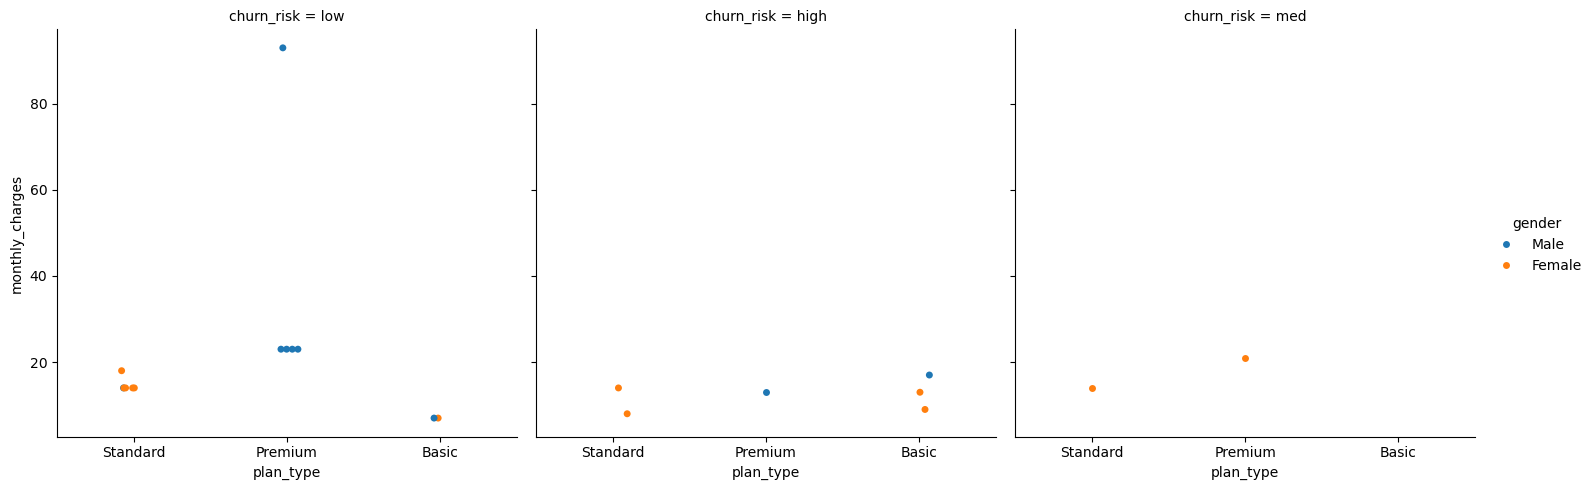

In [165]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

## Pivot table

In [166]:
# Pivot Table


pd.pivot_table(
    df_visual,
    index= 'plan_type',
    values='churn_flag',
    aggfunc= 'mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [170]:
# pivot table using multiple cols and agg type


pd.pivot_table(
    df_visual,
    index= 'plan_type',
    values= ['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc= {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


## Project Completed 

## Working with SQL in Python

In [ ]:
## Working with SQL in Python

conn = sqlite3.connect('test_database.sqlite')


#table details

conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

# commit and save
conn.commit()



print("Cretaed Table successfully!")


Cretaed Table successfully!


In [ ]:
# insert data

cursor = conn.cursor()

# write sql query to insert records in sql table

cursor.execute(
        """
        INSERT INTO users VALUES
            ('Madhav', 'India', 5000),
            ('Rishabh', 'Germany', 2500),
            ('Vishakha', 'India', 3500)
    """
)

# commit and save

conn.commit()


print("Data Inserted successfully!")

In [176]:
# check inserted data in table

conn  = sqlite3.connect('test_database.sqlite')


query = """ SELECT * from users """

df_results = pd.read_sql(query,conn)

df_results.head()


,first_name,country,budget
0,Madhav,India,5000
1,Rishabh,Germany,2500
2,Vishakha,India,3500


In [177]:
# aggregation

query = """
        SELECT country, SUM(budget) as total_budget
        FROM users
        GROUP BY country
"""

df_agg = pd.read_sql(query, conn)

df_agg

,country,total_budget
0,Germany,2500
1,India,8500


In [178]:
# always close the conn with db once the task is over

conn.close()